

### **Name** : **Rashali Bajaj**



### **Dataset** : **Shakespeare Corpus**


---

## **Problem Statement**

Design and implement a deep learning model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using **SimpleRNN, LSTM, and GRU** architectures.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

## Load the Dataset



In [2]:
with open("shakespeare.txt", "r", encoding="utf-8") as file:
    text = file.read()

##  Text Preprocessing

The text is preprocessed by converting it to lowercase, removing unwanted characters, eliminating empty lines, and preserving meaningful sentence structures. This improves the quality of the input data before tokenization.

In [3]:
import re

text = text.lower()

lines = text.splitlines()

lines = [line.strip() for line in lines if line.strip()]

lines = [re.sub(r"[^a-zA-Z\s']", "", line) for line in lines]

## Dataset Customization

To reduce training time while maintaining sufficient data for learning, the first 15,000 cleaned lines of the Shakespeare corpus are selected. This customization enables efficient comparison of the three recurrent neural network models.

In [4]:
lines = lines[:15000]

print("Total Lines Used:", len(lines))

Total Lines Used: 15000


##Tokenization

The cleaned text is converted into numerical form using the Keras `Tokenizer`. Each unique word is assigned a unique integer index, creating the vocabulary required for training the text generation models.

In [5]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(lines)

In [6]:
total_words = min(5000, len(tokenizer.word_index) + 1)

print("Vocabulary Size:", total_words)

Vocabulary Size: 5000


## Generate N-gram Sequences

Each line of the Shakespeare corpus is converted into multiple n-gram sequences using a sliding window approach. These sequences are used to train the model for next-word prediction.

In [7]:
input_sequences = []

for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

In [8]:
print("Total Sequences:", len(input_sequences))

for sequence in input_sequences[:5]:
    print(sequence)

Total Sequences: 74483
[68, 138]
[143, 31]
[143, 31, 884]
[143, 31, 884, 175]
[143, 31, 884, 175, 439]


### Observation

- Total training sequences generated: 74,483.
- The sequences increase progressively in length using the sliding-window approach.
- These sequences will be used for next-word prediction during model training.

## Pad the Sequences



In [9]:
max_sequence_length = max(len(sequence) for sequence in input_sequences)

print("Maximum Sequence Length:", max_sequence_length)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

Maximum Sequence Length: 16


##  Prepare Input and Output Data



In [10]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [11]:
print("Vocabulary Size:", total_words)
print("Maximum Sequence Length:", max_sequence_length)
print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Vocabulary Size: 5000
Maximum Sequence Length: 16
Input Shape: (74483, 15)
Output Shape: (74483,)


## Build the SimpleRNN Model

A Simple Recurrent Neural Network (SimpleRNN) is implemented as the baseline model for next-word prediction.



In [12]:
rnn_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=128
    ),

    SimpleRNN(128),

    Dense(total_words, activation='softmax')
])

In [13]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history_rnn = rnn_model.fit(
    X,
    y,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.0407 - loss: 6.6335 - val_accuracy: 0.0444 - val_loss: 6.4971
Epoch 2/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.0766 - loss: 6.0603 - val_accuracy: 0.0763 - val_loss: 6.2596
Epoch 3/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.0991 - loss: 5.7105 - val_accuracy: 0.0839 - val_loss: 6.1923
Epoch 4/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.1104 - loss: 5.4514 - val_accuracy: 0.0830 - val_loss: 6.1820
Epoch 5/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.1210 - loss: 5.2278 - val_accuracy: 0.0922 - val_loss: 6.1990
Epoch 6/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 0.1316 - loss: 5.0249 - val_accuracy: 0.0879 - val_loss: 6.2470
Epoch 7/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.1429 - loss: 4.8331 - val_accuracy: 0.0884 - val_loss: 6.2941
Epoch 8/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.1562 - loss: 4

### Observation

- The SimpleRNN model completed training successfully for **100 epochs**.
- The training accuracy increased steadily, while the training loss decreased throughout the training process.
- The validation accuracy remained comparatively low and the validation loss increased during later epochs, indicating that the model may be overfitting and has limited ability to generalize.
- These results will be compared with the LSTM and GRU models to evaluate their effectiveness in handling sequential text data.

## Build the LSTM Model

Long Short-Term Memory (LSTM) is an advanced recurrent neural network architecture designed to overcome the limitations of SimpleRNN by learning long-term dependencies using memory cells and gating mechanisms.


In [16]:
lstm_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=128
    ),

    LSTM(128),

    Dense(total_words, activation='softmax')
])

In [17]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_lstm = lstm_model.fit(
    X,
    y,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 54s 111ms/step - accuracy: 0.0349 - loss: 6.6635 - val_accuracy: 0.0395 - val_loss: 6.6124
Epoch 2/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.0509 - loss: 6.2957 - val_accuracy: 0.0517 - val_loss: 6.5038
Epoch 3/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.0708 - loss: 6.0587 - val_accuracy: 0.0632 - val_loss: 6.3826
Epoch 4/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.0893 - loss: 5.8491 - val_accuracy: 0.0768 - val_loss: 6.3110
Epoch 5/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 50s 108ms/step - accuracy: 0.0998 - loss: 5.6891 - val_accuracy: 0.0811 - val_loss: 6.2973
Epoch 6/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.1068 - loss: 5.5526 - val_accuracy: 0.0873 - val_loss: 6.2817
Epoch 7/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.1136 - loss: 5.4316 - val_accuracy: 0.0869 - val_loss: 6.2932
Epoch 8/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - accuracy: 0.1180 -

### Observation

- The LSTM model completed training successfully for **100 epochs**.
- The training loss decreased steadily, while the training accuracy improved throughout the training process.
- The validation accuracy remained relatively low, and the validation loss increased during later epochs, indicating overfitting.
- The performance of the LSTM model will be compared with the SimpleRNN and GRU models to evaluate its effectiveness in text generation.

##  Build the GRU Model

Gated Recurrent Unit (GRU) is a simplified version of LSTM that uses fewer gates while effectively capturing long-term dependencies. GRU generally trains faster than LSTM while achieving comparable performance.


In [20]:
gru_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=128
    ),

    GRU(128),

    Dense(total_words, activation='softmax')
])

In [21]:
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history_gru = gru_model.fit(
    X,
    y,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 54s 110ms/step - accuracy: 0.0409 - loss: 6.6388 - val_accuracy: 0.0416 - val_loss: 6.5123
Epoch 2/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.0669 - loss: 6.1044 - val_accuracy: 0.0689 - val_loss: 6.2974
Epoch 3/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - accuracy: 0.0948 - loss: 5.7765 - val_accuracy: 0.0846 - val_loss: 6.2072
Epoch 4/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - accuracy: 0.1090 - loss: 5.5321 - val_accuracy: 0.0864 - val_loss: 6.1897
Epoch 5/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - accuracy: 0.1186 - loss: 5.3204 - val_accuracy: 0.0901 - val_loss: 6.1984
Epoch 6/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - accuracy: 0.1273 - loss: 5.1202 - val_accuracy: 0.0887 - val_loss: 6.2419
Epoch 7/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.1373 - loss: 4.9211 - val_accuracy: 0.0926 - val_loss: 6.2800
Epoch 8/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.1497 - 

### Observation

- The GRU model completed training successfully for **100 epochs**.
- The training loss decreased consistently, while the training accuracy improved throughout the training process.
- The GRU model demonstrated efficient learning and stable convergence during training.
- The performance of the GRU model will be compared with the SimpleRNN and LSTM models based on training curves, validation performance, and generated text quality.

##  Compare Training Performance

The training loss of the SimpleRNN, LSTM, and GRU models is compared to analyze their learning behavior during training.

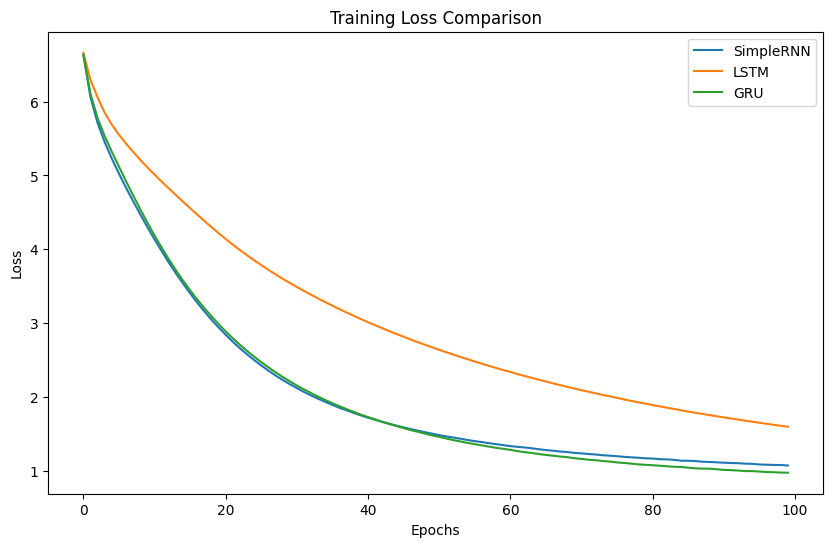

In [24]:
plt.figure(figsize=(10,6))

plt.plot(history_rnn.history['loss'], label='SimpleRNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Observation

- The training loss decreases consistently for all three models, indicating successful learning and convergence.
- GRU achieves the lowest training loss after 100 epochs, followed closely by SimpleRNN.
- LSTM also learns effectively but converges more slowly and retains a comparatively higher training loss.
- Overall, GRU demonstrates the best training performance among the three models on the given dataset.

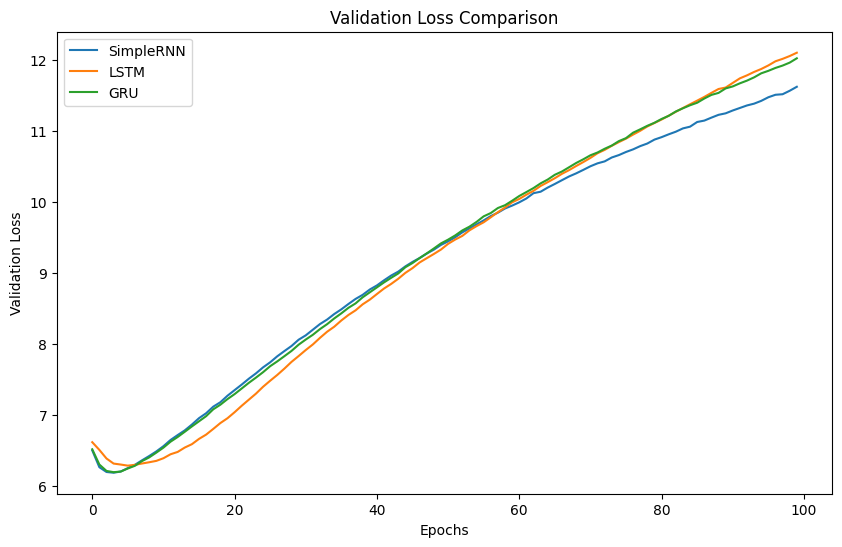

In [25]:
plt.figure(figsize=(10,6))

plt.plot(history_rnn.history['val_loss'], label='SimpleRNN')
plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_gru.history['val_loss'], label='GRU')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()

### Observation

- The validation loss decreases during the initial epochs but increases steadily afterward for all three models.
- The increasing validation loss indicates that the models begin to overfit the training data after the early training phase.
- SimpleRNN achieves the lowest final validation loss, while LSTM and GRU show slightly higher validation losses.
- These results suggest that longer training improves the training performance but does not necessarily improve generalization on the validation data.


Although the training loss continued to decrease, the validation loss increased after the initial epochs, indicating overfitting. This suggests that techniques such as Early Stopping, Dropout, or reducing the number of training epochs could improve the models' generalization performance.

##  Text Generation

The trained models are used to generate text by predicting the next word iteratively from a given seed text.

The same seed text is used for all three models to ensure a fair comparison.

In [26]:
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_length-1,
            padding='pre'
        )

        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [27]:
seed = "the king"

print("SimpleRNN:")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM:")
print(generate_text(lstm_model, seed, 10))

print("\nGRU:")
print(generate_text(gru_model, seed, 10))

SimpleRNN:
the king is dead that stabb'd my edward lives no dispatch'd keeps

LSTM:
the king shall be contented must he lose it so then banish'd

GRU:
the king is sickly weak and melancholy north must exile royal queen


### Observation

- All three models successfully generated text from the same seed phrase.
- The generated sequences demonstrate that the models learned meaningful language patterns from the Shakespeare corpus.
- The quality of generated text varies depending on the recurrent architecture.

## Model Comparison

| Model | Training Performance | Validation Performance |
|--------|----------------------|------------------------|
| SimpleRNN | Fast convergence with low training loss | Lowest validation loss among the three models |
| LSTM | Stable learning but slower convergence | Higher validation loss, indicating overfitting |
| GRU | Lowest training loss and stable convergence | Validation performance comparable to LSTM |


## Conclusion

In this project, SimpleRNN, LSTM, and GRU models were implemented for text generation using the Shakespeare corpus.

After preprocessing the dataset and generating n-gram sequences, all three models were trained for next-word prediction and compared using training loss, validation loss, and generated text.

The training results showed that the GRU model achieved the lowest training loss, while the SimpleRNN model obtained the lowest validation loss on this dataset. The increasing validation loss observed after the initial epochs indicates overfitting in all three models.

Overall, the project demonstrates the effectiveness of recurrent neural networks for text generation and highlights the importance of selecting an appropriate architecture and training strategy.